In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from resources.lattices import geometry, pStrainProperties, effProperties
from resources.calculations import get_ductileData, get_fractureData, calcUT, calcFT

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [22]:
LAT = "tri"
MODEL = "ductile"
l = 0.01  # m
nnx = 30
rD = 0.2

dis = 'per'
nSim = '1-new'

validation = False
psc = False

os.chdir(r"C:\Users\exy053\OneDrive - Queen Mary, University of London\Documents\Research\p1-LatticeFractureToughness\p1git-Lattices\code\data\Ti\tri")
os.chdir(r"C:\Users\exy053\Documents\analysis")

if validation:
    os.chdir(r"C:\Users\exy053\Documents\validation\\"+str(int(l*1000))+'\\'+str(rD))
    dis, nSim = 'per', '1'
elif psc:
    os.chdir(r"C:\Users\exy053\Documents\PerSizeConv4\\"+str(int(l*1000)))
    dis, nSim = 'per', '1'

In [23]:
geom = geometry(LAT, l, nnx, FTcalc=True)

E = 123000e6  ## Pa
v = 0.3
E_pStrain, v_pStrain = pStrainProperties(E, v)
E_eff, v_eff = effProperties(LAT, E_pStrain, rD)

In [24]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    CSVout = f"transfer\OUT-Ductile-{LAT}-{int(nnx)}-{dis}-{nSim}.csv"
    UT_df = get_ductileData(CSVout, crit=0.4)
    print(len(UT_df))

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    CSVout = f"transfer\OUT-Fracture-{LAT}-{int(nnx)}-{dis}-{nSim}.csv"
    FT_df = get_fractureData(CSVout)
    print(len(FT_df))

202


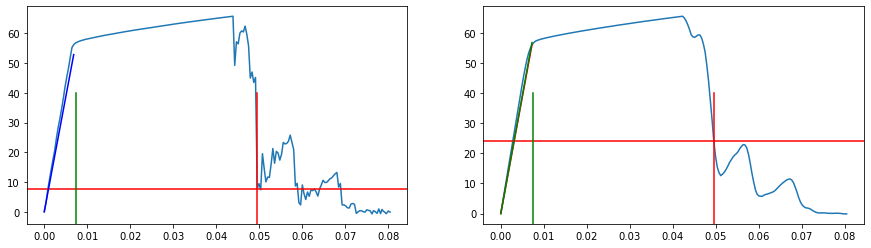

In [25]:
def plt_curve(df):
    frac = int(df.x.tolist()[0])
    x = df.x.tolist()[1:]
    y = df.y.tolist()[1:]
    y_sm = df.y_sm.tolist()[1:]
    
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_figwidth(15)
    
    ax1.plot(x, y)
    ax1.axhline(y=y[frac], c='r')
    ax1.axvline(x=x[frac], ymax=0.6, c='r')

    ax2.plot(x, y_sm)
    #ax2.plot(curves[0], curves[3])
    ax2.axhline(y=y_sm[frac], c='r')
    ax2.axvline(x=x[frac], ymax=0.6, c='r')
    
    slope_loc = 0.15*x.index(x[frac])
    slope_idx = int(slope_loc)
    
    ax1.axvline(x=0.15*x[frac], ymax=0.6, c='g')
    ax2.axvline(x=0.15*x[frac], ymax=0.6, c='g')
        
    ax2.plot([x[0], x[slope_idx]], [y_sm[0], y_sm[slope_idx]], c='r')
    ax2.plot([x[0], x[slope_idx]], [y[0], y[slope_idx]], c='g')
    
    slope = np.average([y_sm[i+1]-y_sm[i] for i in range(slope_idx)])/np.average([x[i+1]-x[i] for i in range(slope_idx)])
    ax1.plot([i for i in x[:slope_idx]], [i*slope for i in x[:slope_idx]], c='b')
    
    plt.show()
    
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    plt_curve(UT_df)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    plt_curve(FT_df)

In [17]:
if MODEL.lower() == "ductile" or MODEL.lower() == "both":
    ductility, strength, stiffness = calcUT(UT_df)
    print(ductility, strength, stiffness)

if MODEL.lower() == "fracture" or MODEL.lower() == "both":
    P, dd, Ks, Kjs = calcFT(FT_df, geom, E_eff, n_Ks=1, validation=validation, E=E)
    K, Kj = Ks[0], Kjs[0]
    print(P, dd, K/(10**6), Kj/(10**6))

0.04953329947686964 65.51866408339453 8632.58532858262


## Old Code